# 2026 07 22 Python 실습 코드

## LSTM 구현

In [1]:
import re
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

I0000 00:00:1784701184.195173   82366 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784701184.339639   82366 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784701186.152454   82366 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
train_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url  = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

train_df = pd.read_table(train_url).dropna(subset=["document"])
test_df  = pd.read_table(test_url).dropna(subset=["document"])

display(train_df.head())
display(test_df.head())

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0


In [3]:
X_train = train_df["document"].astype(str).tolist()
y_train = train_df["label"].values

X_test = test_df["document"].astype(str).tolist()
y_test = test_df["label"].values

In [4]:
def clean_text(text):
  txt = re.sub(r"[^가-힣a-zA-Z]", " ", text)
  txt = re.sub(r"\s+", " ", txt).strip()
  return txt

train_txt = [clean_text(text) for text in X_train]
test_txt  = [clean_text(text) for text in X_test]

In [5]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(train_txt)

x_train = tokenizer.texts_to_sequences(train_txt)
x_test  = tokenizer.texts_to_sequences(test_txt)

max_len = 100

x_train = pad_sequences(x_train, maxlen=max_len, padding='post')
x_test  = pad_sequences(x_test, maxlen=max_len, padding='post')

x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train,
                                            test_size=0.2,
                                            random_state=42)

x_tr.shape, x_val.shape

((119996, 100), (29999, 100))

# 모델 생성 
- 윗부분은 260722실습(3)과 동일 / 아래 모델 구현에서 달라짐

In [9]:
tf.random.set_seed(42)

# 기존 SimpleRNN(64)에서 LSTM(64)로 변경
model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=128,
              input_length=max_len),
    LSTM(64),          # RNN 핵심 레이어
    Dropout(0.3),
    Dense(1, activation="sigmoid")  # 이진분류
])

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['acc'])
model.summary()

/home/siwonl0508/ENTER/envs/deepl_tensor/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# 강제 종료 옵션

# 10번 반복하는 동안 val_loss 모니터 -> 가장 좋은 가중치 복원
es = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

# 최적의 가중치 자동 저장
cp = ModelCheckpoint('./models/0722_best_model.keras', monitor = 'val_loss', save_best_only = True)

In [11]:
history = model.fit(
  x_tr, y_tr,
  validation_data = (x_val, y_val),
  epochs = 30,
  batch_size = 255,
  callbacks = [es,cp],
  verbose = 1
)

Epoch 1/30


I0000 00:00:1784701245.500112   82626 cuda_dnn.cc:461] Loaded cuDNN version 92500


471/471 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - acc: 0.5020 - loss: 0.6933 - val_acc: 0.4985 - val_loss: 0.6932
Epoch 2/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - acc: 0.5028 - loss: 0.6933 - val_acc: 0.4985 - val_loss: 0.6932
Epoch 3/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - acc: 0.5013 - loss: 0.6933 - val_acc: 0.4985 - val_loss: 0.6932
Epoch 4/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - acc: 0.5000 - loss: 0.6933 - val_acc: 0.4985 - val_loss: 0.6932
Epoch 5/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - acc: 0.4996 - loss: 0.6932 - val_acc: 0.4985 - val_loss: 0.6932
Epoch 6/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - acc: 0.5012 - loss: 0.6932 - val_acc: 0.4985 - val_loss: 0.6932
Epoch 7/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - acc: 0.5015 - loss: 0.6932 - val_acc: 0.4985 - val_loss: 0.6932
Epoch 8/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - acc: 0.5030 - loss: 0.6932 - val_acc: 0.4985 - val_loss: 0.6932
Epoch 9/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - acc

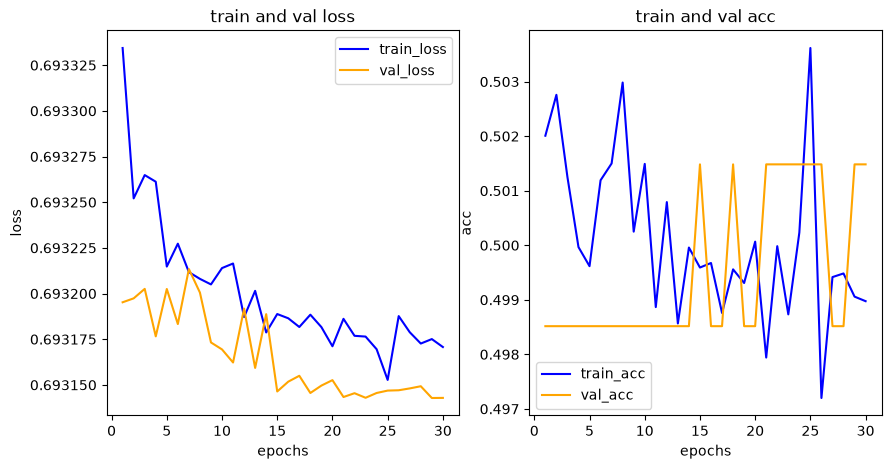

In [12]:
import matplotlib.pyplot as plt

his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss']

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize = (10, 5))

# 훈련 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color = 'blue', label = 'train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label = 'val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

# 훈련 및 검증 정확도 그리기
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label = 'train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label = 'val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

In [13]:
# Test 셋으로 모델 검증
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"NSMC Test Loss: {loss:.4f}, Test Acc: {acc:.4f}")

NSMC Test Loss: 0.6932, Test Acc: 0.4965


In [15]:
def predict_sentiment_kor(text: str):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_len, padding="post")
    prob = float(model.predict(seq, verbose=0)[0][0])
    label = "긍정" if prob >= 0.5 else "부정"
    print(f"[{label}] prob={prob:.3f} | {text}")

predict_sentiment_kor("연기가 너무 좋고 스토리도 감동적이었어요!!!!!!!")
predict_sentiment_kor("지루하고 시간 아까운 영화였습니다")

[부정] prob=0.499 | 연기가 너무 좋고 스토리도 감동적이었어요
[부정] prob=0.499 | 지루하고 시간 아까운 영화였습니다
